<div style="background:linear-gradient(135deg,#78350f 0%,#b45309 55%,#f59e0b 100%);border-radius:18px;padding:32px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#fde68a;font-weight:700;text-transform:uppercase">Chapter 161 &middot; Capstone 2 &middot; Two-Sample t-Test</div>
  <div style="font-size:32px;font-weight:900;line-height:1.1;margin:10px 0 6px">Does the New Onboarding Work?</div>
  <div style="font-size:15px;color:#fef3c7;max-width:780px;line-height:1.6">Two groups of new hires, one on a redesigned onboarding program and one on the old one, and a single question: does the new program get people productive faster? A full pass through the framework, where checking equal variances changes which test we are allowed to run.</div>
</div>

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import pingouin as pg
plt.rcParams.update({"figure.dpi":110,"font.size":11,"axes.spines.top":False,"axes.spines.right":False,
    "axes.grid":True,"grid.alpha":0.22,"axes.titleweight":"bold","axes.titlesize":12.5,"axes.titlelocation":"left"})
GOLD, AMBER, DARK, BL, RD, GR, MUT = "#b45309", "#d97706", "#78350f", "#2563eb", "#dc2626", "#16a34a", "#94a3b8"
COL = {"Standard": MUT, "New": GOLD}

BASE = "https://raw.githubusercontent.com/johnfisher-ai/Statistics-Data-Science-AI-Visual-Book/main/data/"
fn = "capstone-onboarding-productivity.xlsx"
try: raw = pd.read_excel("../../data/" + fn, sheet_name="hires")
except FileNotFoundError: raw = pd.read_excel(BASE + fn, sheet_name="hires")
print("loaded", raw.shape[0], "rows")
raw.head()

loaded 115 rows


,employee_id,cohort,department,days_to_productive
0,E1045,Standard,Operations,28.1
1,E1005,Standard,Engineering,28.8
2,E1006,Standard,Support,22.6
3,E2045,new,Operations,27.8
4,E1055,standard,Support,28.2


## Step 1 &middot; Goal and hypotheses
A company redesigned its onboarding and piloted it (the **New** program) alongside the existing one (**Standard**). For each hire we have the number of business days until they hit the productivity bar, so lower is better. The question is whether the new program shortens that time on average.

Two independent groups, one continuous outcome, compared by their means.
- **H&#8320; (null):** the mean time-to-productive is the same for New and Standard.
- **H&#8321; (alternative):** the two means differ.
- **&#945; = 0.05**, two-sided (we would want to know if the new program were slower, too).

## Step 2 &middot; Know the data types
The outcome, `days_to_productive`, is **continuous**. The grouping variable, `cohort`, is **nominal with two levels** (New, Standard). A continuous outcome split by a two-level group points to the **two-sample t-test**, once we check its assumptions.

In [2]:
print(raw.dtypes)
print("\ncohort labels as they arrived (note the inconsistent casing/spacing):")
print(raw.cohort.value_counts(dropna=False).to_string())

employee_id               str
cohort                    str
department                str
days_to_productive    float64
dtype: object

cohort labels as they arrived (note the inconsistent casing/spacing):
cohort
Standard     24
Standard     20
new          20
New          19
New          17
standard     15


## Step 3 &middot; Describe the groups
Group sizes, means, and spread, side by side. Read the spread as carefully as the average: a program can lower the average time and still be less predictable.

In [3]:
print("rows:", len(raw), " unique employees:", raw.employee_id.nunique())
print("\nraw days_to_productive summary:")
print(raw.days_to_productive.describe().round(2).to_string())

rows: 115  unique employees: 113

raw days_to_productive summary:
count    112.00
mean      30.45
std       92.63
min       -4.00
25%       17.60
50%       22.65
75%       27.35
max      999.00


## Step 4 &middot; Visualize first
Before testing, look. Overlaid distributions and boxplots show the New group shifted toward fewer days, and hint at something the means alone hide: the New group looks more spread out.

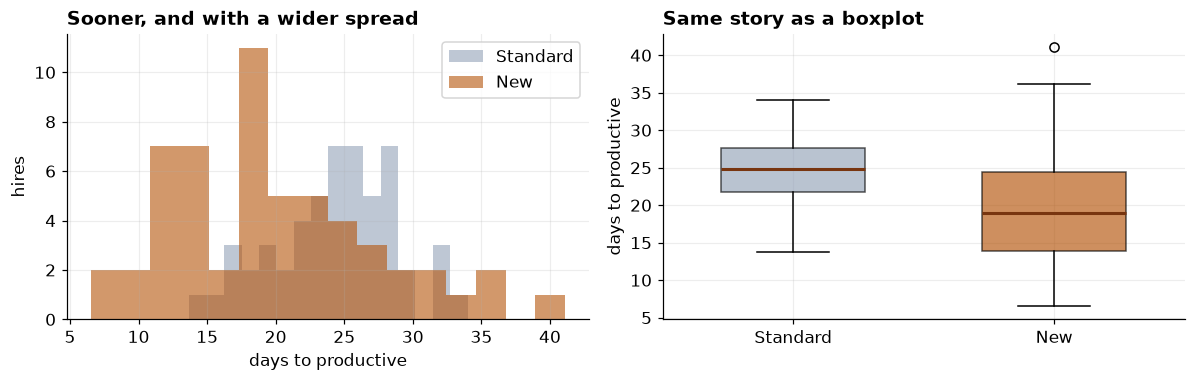

In [4]:
tmp = raw.copy()
tmp["c"] = tmp.cohort.str.strip().str.title()
tmp = tmp[(tmp.days_to_productive>=1) & (tmp.days_to_productive<=120)]
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
for g in ["Standard","New"]:
    ax[0].hist(tmp[tmp.c==g].days_to_productive, bins=16, alpha=0.6, label=g, color=COL[g])
ax[0].set_title("Sooner, and with a wider spread")
ax[0].set_xlabel("days to productive"); ax[0].set_ylabel("hires"); ax[0].legend()
data = [tmp[tmp.c==g].days_to_productive.values for g in ["Standard","New"]]
bp = ax[1].boxplot(data, tick_labels=["Standard","New"], patch_artist=True, widths=0.55)
for patch, g in zip(bp["boxes"], ["Standard","New"]): patch.set_facecolor(COL[g]); patch.set_alpha(0.65)
for med in bp["medians"]: med.set_color(DARK); med.set_linewidth(2)
ax[1].set_title("Same story as a boxplot"); ax[1].set_ylabel("days to productive")
plt.tight_layout(); plt.show()

## Step 5 &middot; Prepare and clean
Four fixes: the `cohort` labels arrived inconsistently cased and spaced, so we **standardize** them first; then drop **duplicate rows**, **missing times**, and **impossible values** (a valid time-to-productive is between 1 and 120 business days, so a 0, a negative, and a 999 placeholder all go).

In [5]:
df = raw.copy()
df["cohort"] = df.cohort.str.strip().str.title()           # "standard ", "New " -> "Standard", "New"
before = len(df)
df = df.drop_duplicates(); after_dup = len(df)
df = df.dropna(subset=["days_to_productive"]); after_na = len(df)
bad = df[(df.days_to_productive < 1) | (df.days_to_productive > 120)]
df = df[(df.days_to_productive >= 1) & (df.days_to_productive <= 120)].copy()
print("cohort labels after cleaning:", sorted(df.cohort.unique()))
print(f"start {before}  ->  dedup {after_dup} (-{before-after_dup})  ->  dropna {after_na} (-{after_dup-after_na})")
print("impossible values removed:", sorted(bad.days_to_productive.tolist()))
print(f"clean analysis sample: n = {len(df)}")

cohort labels after cleaning: ['New', 'Standard']
start 115  ->  dedup 113 (-2)  ->  dropna 110 (-3)
impossible values removed: [-4.0, 0.0, 999.0]
clean analysis sample: n = 107


In [6]:
std = df[df.cohort=="Standard"].days_to_productive.values
new = df[df.cohort=="New"].days_to_productive.values
for name, x in [("Standard", std), ("New", new)]:
    print(f"{name:9s}  n={len(x):3d}  mean={x.mean():.2f}  sd={x.std(ddof=1):.2f} days")
print(f"\nobserved difference (Standard - New): {std.mean()-new.mean():+.2f} days faster for New")

Standard   n= 52  mean=24.56  sd=4.43 days
New        n= 55  mean=19.88  sd=7.59 days

observed difference (Standard - New): +4.68 days faster for New


## Step 6 &middot; Name the design
Two **independent** groups of different people, one continuous outcome. Nobody appears in both groups, so this is not a paired design. That leaves the two-sample t-test, and its two flavors: the classic pooled test (which assumes the groups share one variance) and Welch's test (which does not). Step 7 decides which one we are allowed to use.

## Step 7 &middot; Check the assumptions
Two things to check: is each group roughly **normal**, and do the groups have **equal variance**? Normality we test with Shapiro-Wilk and Q-Q plots; equal variance with **Levene's test** (robust) and **Bartlett's test**.

Standard  Shapiro-Wilk p = 0.745  -> normal enough
New       Shapiro-Wilk p = 0.115  -> normal enough

Levene's test  p = 0.0018   -> variances differ
Bartlett's test p = 0.0002   -> variances differ

sd Standard = 4.43,  sd New = 7.59  (ratio 1.71x)


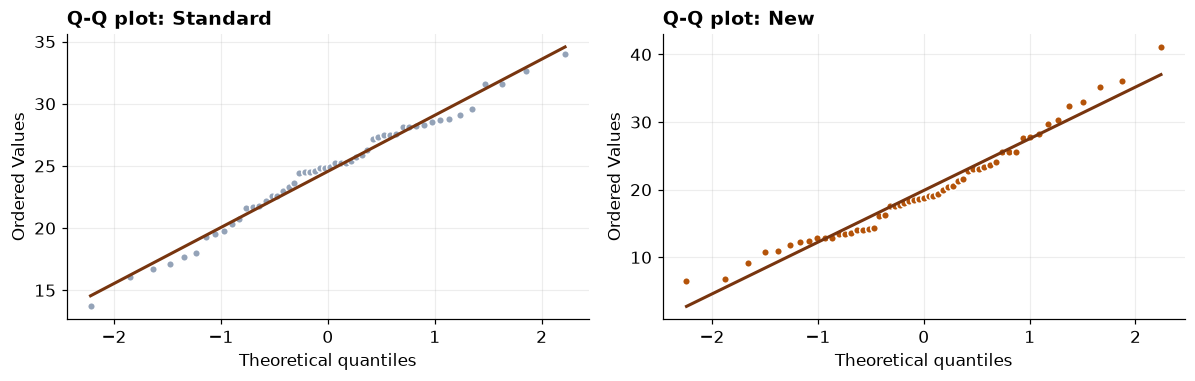

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
for g, x in [("Standard", std), ("New", new)]:
    print(f"{g:9s} Shapiro-Wilk p = {stats.shapiro(x).pvalue:.3f}  -> {'normal enough' if stats.shapiro(x).pvalue>0.05 else 'not normal'}")
lev = stats.levene(std, new); bart = stats.bartlett(std, new)
print(f"\nLevene's test  p = {lev.pvalue:.4f}   -> variances {'differ' if lev.pvalue<0.05 else 'look equal'}")
print(f"Bartlett's test p = {bart.pvalue:.4f}   -> variances {'differ' if bart.pvalue<0.05 else 'look equal'}")
print(f"\nsd Standard = {std.std(ddof=1):.2f},  sd New = {new.std(ddof=1):.2f}  (ratio {new.std(ddof=1)/std.std(ddof=1):.2f}x)")
for a_, (g, x) in zip(ax, [("Standard", std), ("New", new)]):
    stats.probplot(x, dist="norm", plot=a_)
    a_.get_lines()[0].set(marker="o", markerfacecolor=COL[g], markeredgecolor="white", markersize=5)
    a_.get_lines()[1].set(color=DARK, lw=2); a_.set_title(f"Q-Q plot: {g}")
plt.tight_layout(); plt.show()

## Step 8 &middot; Decide, and fix
Both groups pass the normality check, so a t-test is appropriate. But Levene's and Bartlett's tests both say the **variances are not equal**: the New group is noticeably more spread out (its standard deviation is over 1.7 times the Standard group's). That rules out the classic pooled t-test, whose formula assumes a single shared variance. The fix is not to abandon the t-test, it is to use **Welch's version**, which allows the two groups to have different variances. Welch's t is the safe default for two independent groups, and here it is not optional.

## Step 9 &middot; Choose the test
- **Primary:** Welch's two-sample t-test (unequal variances).
- **Robustness check:** Mann-Whitney U, which assumes neither normality nor equal variance.
- **Reported alongside:** Cohen's d and the 95% confidence interval for the difference in means.

## Step 10 &middot; Run the test and report fully
`scipy` runs Welch's t with `equal_var=False`; `pingouin` reports the effect size, the confidence interval for the difference, and the power. We show the pooled result too, only to see how the wrong choice would have differed, then confirm with Mann-Whitney.

In [8]:
tw, pw = stats.ttest_ind(std, new, equal_var=False)   # Welch (correct here)
tp, pp = stats.ttest_ind(std, new, equal_var=True)    # pooled (assumes equal var) -- shown for contrast
print(f"Welch's t-test : t = {tw:.3f},  p = {pw:.2e}   <- the one we report")
print(f"pooled t-test  : t = {tp:.3f},  p = {pp:.2e}   (assumes equal variance; not valid here)")

res = pg.ttest(std, new, correction=True)   # correction=True => Welch
print("\npingouin (Welch):")
print(res[["T","dof","alternative","cohen_d","power"]].round(3).to_string(index=False))
ci = res["CI95"].iloc[0]; d = float(res["cohen_d"].iloc[0])
print(f"\ndifference (Standard - New): {std.mean()-new.mean():.2f} days")
print(f"95% CI for the difference: [{ci[0]:.2f}, {ci[1]:.2f}] days")
print(f"Cohen's d = {d:.3f}  ({'small' if d<0.5 else 'medium' if d<0.8 else 'large'} effect)")

u, pu = stats.mannwhitneyu(std, new, alternative="two-sided")
print(f"\nMann-Whitney U (robustness): U = {u:.1f}, p = {pu:.2e}  -> same conclusion")

Welch's t-test : t = 3.920,  p = 1.75e-04   <- the one we report
pooled t-test  : t = 3.866,  p = 1.92e-04   (assumes equal variance; not valid here)



pingouin (Welch):
   T    dof alternative  cohen_d  power
3.92 87.815   two-sided    0.748  0.969

difference (Standard - New): 4.68 days
95% CI for the difference: [2.31, 7.05] days
Cohen's d = 0.748  (medium effect)

Mann-Whitney U (robustness): U = 2063.0, p = 8.06e-05  -> same conclusion


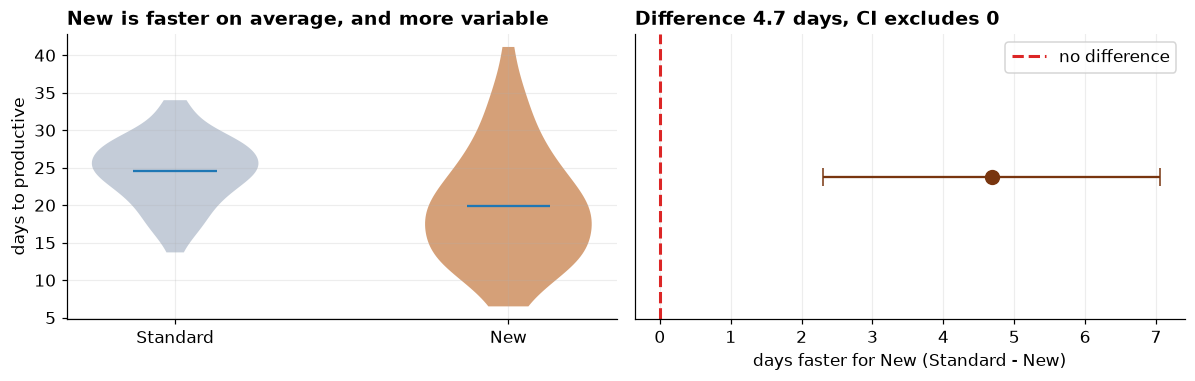

In [9]:
# Result in one picture: group distributions + the difference with its 95% CI.
tcrit = stats.t.ppf(0.975, res["dof"].iloc[0])
diff = std.mean() - new.mean(); se_diff = (std.var(ddof=1)/len(std) + new.var(ddof=1)/len(new))**0.5
lo, hi = diff - tcrit*se_diff, diff + tcrit*se_diff
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
parts = ax[0].violinplot([std, new], showmeans=True, showextrema=False)
for pc, g in zip(parts["bodies"], ["Standard","New"]): pc.set_facecolor(COL[g]); pc.set_alpha(0.55)
ax[0].set_xticks([1,2]); ax[0].set_xticklabels(["Standard","New"]); ax[0].set_ylabel("days to productive")
ax[0].set_title("New is faster on average, and more variable")
ax[1].errorbar([diff], [0], xerr=[[diff-lo],[hi-diff]], fmt="o", color=DARK, capsize=6, markersize=9)
ax[1].axvline(0, color=RD, lw=2, ls="--", label="no difference")
ax[1].set_yticks([]); ax[1].set_xlabel("days faster for New (Standard - New)")
ax[1].set_title(f"Difference {diff:.1f} days, CI excludes 0"); ax[1].legend()
plt.tight_layout(); plt.show()

## Step 11 &middot; Estimate, do not just test
The test said the new onboarding is faster. The business question is how much faster, and how confident we are in that figure.

In [10]:
# A percentile bootstrap: resample the data with replacement, recompute, repeat.
# Chapter 73 introduced this; it is how we get an interval when no formula exists.
def boot_ci(data, stat, B=10000, seed=11, ci=95):
    rng = np.random.default_rng(seed)
    data = np.asarray(data)
    reps = np.array([stat(rng.choice(data, size=len(data), replace=True)) for _ in range(B)])
    half = (100 - ci) / 2
    return np.percentile(reps, half), np.percentile(reps, 100 - half), reps

def boot_ci_pairs(a, b, stat, B=10000, seed=11, ci=95):
    """Bootstrap for two paired/related arrays: resample ROW indices together."""
    rng = np.random.default_rng(seed)
    a, b = np.asarray(a), np.asarray(b)
    idx = np.arange(len(a))
    reps = np.array([stat(a[i], b[i]) for i in
                     (rng.choice(idx, size=len(idx), replace=True) for _ in range(B))])
    reps = reps[np.isfinite(reps)]
    half = (100 - ci) / 2
    return np.percentile(reps, half), np.percentile(reps, 100 - half), reps

def boot_ci_groups(groups, stat, B=10000, seed=11, ci=95):
    """Bootstrap for k independent groups: resample within each group."""
    rng = np.random.default_rng(seed)
    groups = [np.asarray(g) for g in groups]
    reps = []
    for _ in range(B):
        rs = [rng.choice(g, size=len(g), replace=True) for g in groups]
        v = stat(rs)
        if np.isfinite(v):
            reps.append(v)
    reps = np.array(reps)
    half = (100 - ci) / 2
    return np.percentile(reps, half), np.percentile(reps, 100 - half), reps

print(f"difference in means    {diff:.2f} days   95% CI [{lo:.2f}, {hi:.2f}] days")
print(f"margin of error        +/- {(hi-lo)/2:.2f} days\n")

# An interval for Cohen's d. Both groups are resampled independently.
d_lo, d_hi, _ = boot_ci_groups([std, new],
    lambda g: (g[0].mean() - g[1].mean()) /
              np.sqrt(((len(g[0])-1)*g[0].var(ddof=1) + (len(g[1])-1)*g[1].var(ddof=1)) /
                      (len(g[0]) + len(g[1]) - 2)))
print(f"Cohen's d              {d:.2f}         95% CI [{d_lo:.2f}, {d_hi:.2f}]")

# The second headline was about SPREAD, so give that an interval as well.
r_lo, r_hi, _ = boot_ci_groups([std, new], lambda g: g[1].std(ddof=1) / g[0].std(ddof=1))
print(f"SD ratio (New/Standard) {new.std(ddof=1)/std.std(ddof=1):.2f}        95% CI [{r_lo:.2f}, {r_hi:.2f}]")

difference in means    4.68 days   95% CI [2.31, 7.05] days
margin of error        +/- 2.37 days



Cohen's d              0.75         95% CI [0.36, 1.22]


SD ratio (New/Standard) 1.71        95% CI [1.31, 2.24]


**Reading the intervals.** The new cohort reaches productivity somewhere between about 2.3 and 7.1 days sooner. That range matters for planning: at the bottom end the change is a nice-to-have, at the top end it is most of a working week per hire. Reporting "4.7 days faster" alone hides which of those worlds we are in.

The spread ratio also gets an interval, and it stays clear of 1.0, which is what licenses the second headline: the new program is genuinely more variable, not just variable in this sample.

## Step 12 &middot; Were the two groups comparable to begin with?
The dataset carries a `department` column that the analysis has not touched. Before crediting the program with the difference, it is worth checking that the two cohorts were not drawn from different parts of the business.

In [11]:
tab = pd.crosstab(df.cohort, df.department)
print(tab.to_string())
print()
print((tab.div(tab.sum(axis=1), axis=0) * 100).round(1).to_string())
chi2_bal, p_bal, dof_bal, exp_bal = stats.chi2_contingency(tab)
print(f"\nbalance check: chi-square = {chi2_bal:.2f}, df = {dof_bal}, p = {p_bal:.3f}")
print("(a LARGE p here is the reassuring result: no detectable imbalance in department mix)\n")
for dep in sorted(df.department.unique()):
    sub = df[df.department == dep]
    print(f"  {dep:14s} n = {len(sub):3d}   median days to productive = {sub.days_to_productive.median():.0f}")

department  Engineering  Operations  Sales  Support
cohort                                             
New                   9           9     18       19
Standard             11          14     16       11

department  Engineering  Operations  Sales  Support
cohort                                             
New                16.4        16.4   32.7     34.5
Standard           21.2        26.9   30.8     21.2

balance check: chi-square = 3.46, df = 3, p = 0.326
(a LARGE p here is the reassuring result: no detectable imbalance in department mix)

  Engineering    n =  20   median days to productive = 25
  Operations     n =  23   median days to productive = 22
  Sales          n =  34   median days to productive = 23
  Support        n =  30   median days to productive = 22


**Why this check belongs here.** If the new cohort had been drawn disproportionately from a department where people ramp up quickly anyway, the difference we measured would be a department effect wearing the program's badge. That is confounding, and no amount of care with the t-test would have caught it.

The check comes back clean: department mix does not differ detectably between cohorts (chi-square = 3.46, p = 0.33), so the comparison is not obviously contaminated. Note the logic, because it runs backwards from the rest of the chapter. Here a **large** p-value is the reassuring one. It is still not proof of balance, only an absence of detectable imbalance, which is the strongest claim an observational check of this kind can make.

## Step 13 &middot; Interpret in plain language
New hires on the redesigned program reach productivity about **4.7 days sooner** on average (roughly 20 days versus 25). Welch's test says a gap that size is very unlikely to be chance (p well below 0.001), and the 95% confidence interval for the difference, about **2 to 7 days**, stays entirely above zero. The effect size is medium-to-large. So the new program clearly works on average. But the spread is the second headline: the New group is far more variable, so while most hires do better, the program is less consistent, and a few take as long as the old one or longer.

## Step 14 &middot; Ethics, bias, and limits
- **Assignment.** The cleanest version of this study assigns hires to programs at random. If instead the New program went to a particular set of hires (one department, one manager, a later start date), the difference could reflect those people or that period, not the program. Check that the groups are comparable on department and start date before crediting the program.
- **The variance matters, not just the mean.** Reporting only "4.7 days faster" hides that the new program is less predictable. For workforce planning, a wider spread is a real cost, and it deserves to be in the recommendation.
- **Outcome definition.** "Time to productive" is only as trustworthy as the bar that defines it. If managers apply that bar differently, part of the gap could be measurement, not learning speed.
- **Generalization.** This is one pilot at one company. It supports rolling the program forward with monitoring, not a claim that it will help everywhere.

---
**From analysis to report.** The notebook carries the evidence: the cleaning trail, the assumption checks that forced Welch's test, the difference with its interval, and the variance caveat. The written report turns it into a recommendation an HR director can act on, leading with the decision and keeping the statistics in plain language. Automate the evidence; author the argument.